# Determining Ideal Simulation Size

## Imports and constants

In [1]:
import numpy as np
from astropy import units as u, constants as c
from matplotlib import pyplot as plt

import sys
sys.path.append("..")
from oskareor.skalow_calc import SKAMath as omath, EoRCosmology as Cosmo

In [2]:
STATION_DIAMETER = 38 * u.m

## Calculating the SKA primary beam size

For the airy disk we will use the calculation for the first minimum, as that is where we can ensure the primary beam edges fully obscure any corner or side-of-box data.

In [3]:
# Create array of redshift values from 5 to 12 inclusive, use 71 entries (i.e. a redshift step of 0.1)
zs = np.linspace(5, 12, 71)

# Frequencies and wavelengths
fs = omath.FREQ_21CM / (zs + 1)
λs = c.c / fs

# Airy disk first minimum
θs = np.asin(1.22 * λs / STATION_DIAMETER).to(u.deg)

print(θs)

[2.33011909 2.36897637 2.40783474 2.44669422 2.48555483 2.52441658
 2.56327949 2.60214358 2.64100887 2.67987538 2.71874312 2.75761211
 2.79648238 2.83535393 2.87422679 2.91310097 2.95197649 2.99085338
 3.02973164 3.0686113  3.10749237 3.14637487 3.18525883 3.22414426
 3.26303117 3.30191958 3.34080952 3.379701   3.41859404 3.45748866
 3.49638487 3.53528269 3.57418215 3.61308325 3.65198603 3.69089049
 3.72979665 3.76870454 3.80761417 3.84652555 3.88543871 3.92435367
 3.96327044 4.00218904 4.04110949 4.08003181 4.11895602 4.15788213
 4.19681016 4.23574014 4.27467207 4.31360598 4.35254188 4.3914798
 4.43041976 4.46936176 4.50830583 4.54725199 4.58620025 4.62515064
 4.66410317 4.70305786 4.74201474 4.7809738  4.81993509 4.8588986
 4.89786437 4.93683241 4.97580275 5.01477538 5.05375035] deg


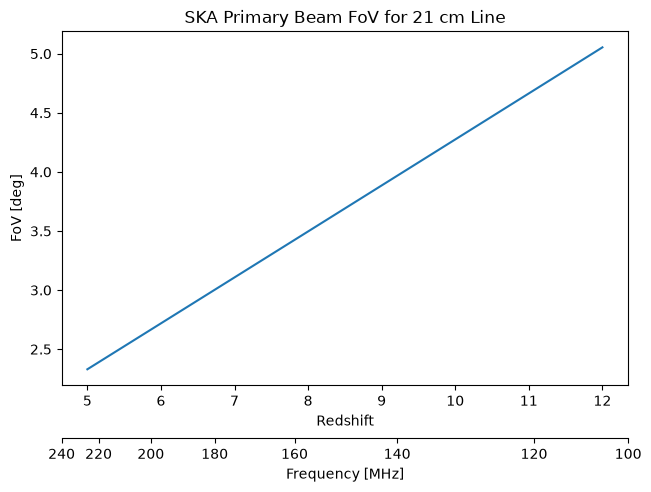

In [4]:
fig, ax = plt.subplots(layout='constrained')

ax.plot(zs, θs)
ax.set_xlabel("Redshift")
ax.set_ylabel("FoV [deg]")
ax.set_title("SKA Primary Beam FoV for 21 cm Line")

# Create a unitless array
fs_mhz = fs.to_value(u.MHz)

z2f = lambda z: np.interp(z, zs, fs_mhz)

f2z = lambda f: np.interp(f, fs_mhz[::-1], zs[::-1])

secax = ax.secondary_xaxis(-0.15, functions=(z2f, f2z))
secax.set_xlabel("Frequency [MHz]")

plt.show()

## Defining Cosmology

Next we need to set the cosmology of the universe so that we can analyse the primary beam in-terms of comoving distance. This will use the already-existing cosmology object that I have made for the reformatter. This uses $H_0=100h, h=0.68$.

In [5]:
cosmo = Cosmo() # Planck survey parameters w/ H0 = 100

print(cosmo.cosmo)

FlatLambdaCDM(H0=100.0 km / (Mpc s), Om0=0.31, Tcmb0=0.0 K, Neff=3.04, m_nu=None, Ob0=0.048)


We can thus, for example, calculate the relationship between redshift, frequency and comoving distance:

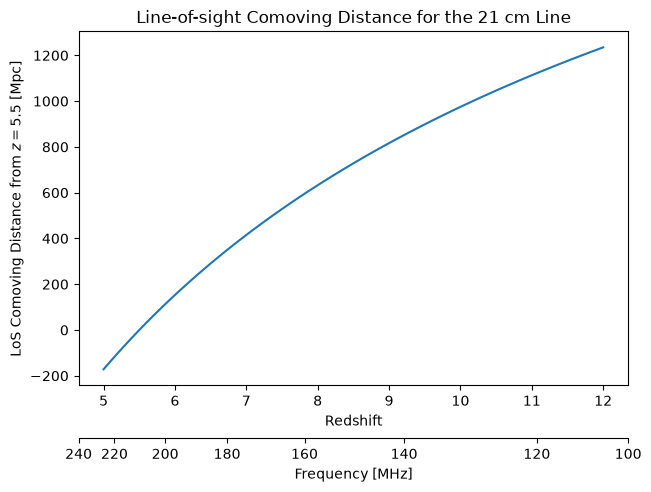

In [6]:
ds = cosmo.z_to_dz(zs)

d_ref = cosmo.z_to_dz(5.5)

fig, ax = plt.subplots(layout='constrained')

ax.plot(zs, ds - d_ref)
ax.set_xlabel("Redshift")
ax.set_ylabel("LoS Comoving Distance from $z = 5.5$ [Mpc]")
ax.set_title("Line-of-sight Comoving Distance for the 21 cm Line")

# Create a unitless array
fs_mhz = fs.to_value(u.MHz)

z2f = lambda z: np.interp(z, zs, fs_mhz)
f2z = lambda f: np.interp(f, fs_mhz[::-1], zs[::-1])

secax = ax.secondary_xaxis(-0.15, functions=(z2f, f2z))
secax.set_xlabel("Frequency [MHz]")

plt.show()

I'm using z = 5.5 as the ideal start point as it might be unnecessary looking at the EoR below such a value, even given a late start to the EoR.

## Getting the Primary Beam in cMpc

Next we can simply apply the calculation built into the cosmology class to get the primary beam size in units of comoving distance. This is calculated using the modified arc length formula $s=r\tan{\theta}$.

In [7]:
ds = np.tan(θs.to(u.rad)) * cosmo.z_to_dz(zs)

print(ds)

[219.08262242 224.22969149 229.38956571 234.56194077 239.74652564
 244.94304173 250.1512222  255.37081127 260.60156358 265.84324359
 271.09562512 276.35849076 281.63163145 286.91484604 292.20794087
 297.51072942 302.82303195 308.14467512 313.47549177 318.81532054
 324.16400565 329.52139665 334.88734814 340.26171955 345.64437498
 351.03518293 356.43401613 361.8407514  367.25526941 372.6774546
 378.10719494 383.54438188 388.98891012 394.44067755 399.89958511
 405.36553666 410.83843885 416.31820107 421.80473532 427.29795609
 432.79778032 438.30412726 443.81691843 449.33607751 454.86153031
 460.39320462 465.93103022 471.47493879 477.0248638  482.58074051
 488.14250592 493.71009863 499.28345888 504.86252845 510.44725064
 516.03757018 521.63343323 527.23478731 532.84158127 538.45376525
 544.07129065 549.69411005 555.32217725 560.95544717 566.59387583
 572.23742035 577.88603889 583.53969065 589.19833578 594.86193543
 600.53045167] Mpc


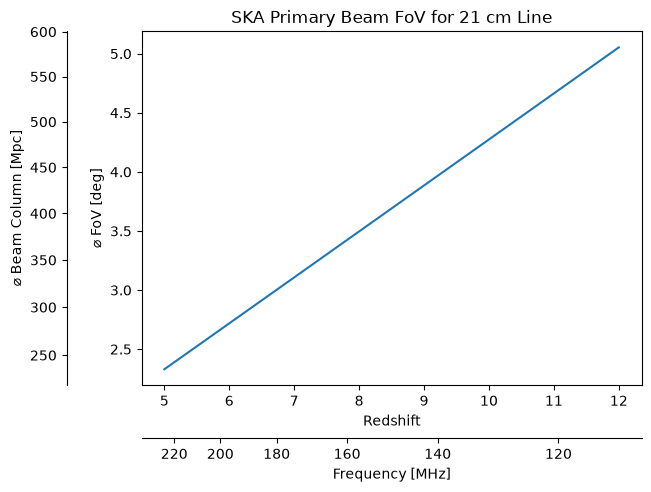

In [8]:
def plot_on_four_axes(zs, θs, fs, ds, f_ticks = 20, d_ticks = 50):
    fig, ax = plt.subplots(layout='constrained')

    ax.plot(zs, θs)
    ax.set_xlabel("Redshift")
    ax.set_ylabel("⌀ FoV [deg]")
    ax.set_title("SKA Primary Beam FoV for 21 cm Line")

    fs_mhz = fs.to_value(u.MHz)

    z2f = lambda z: np.interp(z, zs, fs_mhz)
    f2z = lambda f: np.interp(f, fs_mhz[::-1], zs[::-1])

    secax = ax.secondary_xaxis(-0.15, functions=(z2f, f2z))
    secax.set_xlabel("Frequency [MHz]")
    secax.set_xticks(np.arange(np.trunc(1 + fs_mhz[-1] / f_ticks) * f_ticks, fs_mhz[0], f_ticks))

    θs_deg = θs.to_value(u.deg)
    ds_mpc = ds.to_value(u.Mpc)

    θ2d = lambda θ: np.interp(θ, θs_deg, ds_mpc)
    d2θ = lambda d: np.interp(d, ds_mpc, θs_deg)

    terax = ax.secondary_yaxis(-0.15, functions=(θ2d, d2θ))
    terax.set_ylabel("⌀ Beam Column [Mpc]")
    terax.set_yticks(np.arange(np.trunc(1 + ds_mpc[0] / d_ticks) * d_ticks, ds_mpc[-1], d_ticks))

    return fig, ax, secax, terax

_ = plot_on_four_axes(zs, θs, fs, ds)

plt.show()

## Comparing with simulation boxes

We will consider in all cases that any simulation box produced by `21cmFast` are 1 Mpc across, all that would mean is the number of voxels per side can be reduced by a factor of 2 if needed, as the maximum we can do is voxels 2 Mpc on a side.

From this we consider box sizes that have some multiple of 256 voxels per side. Additionally, the Meraxes coeval box was 600 Mpc across with 1.5 Mpc voxels — this will be used as a sanity check to assure the calculated primary beam is of a reasonable size.

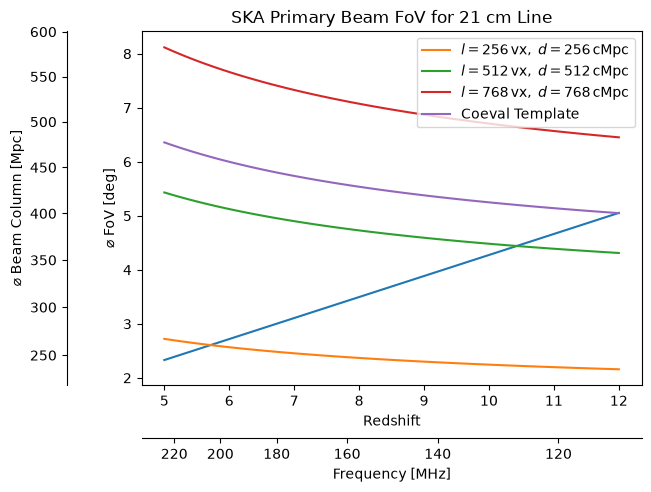

In [9]:
vl = 1 * u.Mpc

def get_sizes(zs, n, vox_len = 1 * u.Mpc):
    # Calculate side length of box
    side = n * vox_len
    
    # From side length we can calculate the subtended angle
    return np.atan(side / cosmo.z_to_dz(zs)).to(u.deg)

ns = np.arange(1, 4, 1) * 256

fig, ax, _, _ = plot_on_four_axes(zs, θs, fs, ds)

# Non-Meraxes Boxes
for n in ns:
    ax.plot(zs, get_sizes(zs, n, vl), label = "$l=%d\,\mathrm{vx},\;d=%d\,\mathrm{cMpc}$" % (n, (n * vl).to_value(u.Mpc)))

# Meraxes Boxes
ax.plot(zs, get_sizes(zs, 400, vl * 1.5), label = "Coeval Template")

plt.legend()
plt.show()

As it appears, a 768 cubed box with side length of 768 cMpc is able to stay above the primary beam size for all redshifts. If we used 1.5 cMpc for each voxel the equivalent side length would correspond to a 512 cubed box.

Now reminder that, for the coeval template, at the lowest frequency (125 MHz), the *corners* of the box was *barely* obscured by the primary beam. However, in this graph, the coeval box *edges* should be decently obscured by the beam:

![box](./Screenshot%20from%202026-08-04%2019-58-58.png)

But from the graph above, it is at almost exactly 600 Mpc that the box edges should be fully obscured by the primary beam.

So the next step is to scale the primary beam size to make it fit the data. There are two scaling factors to consider:
- Since only the edges were being obscured, the primary beam has to be at least a factor of $\sqrt{2}$ larger
- The 512 cMpc box seems to have its intersection point at a more correct location — that being a bit above z = 10; i.e. a factor of $600/512\approx1.17$
- To be safe, I am going to multiply by the Airy disk multiplication parameter 1.22 again (to account for how the box was 'barely obscured')

These factors would combine to produce a scaling factor of $1.41 \times 1.17 \times 1.22 \approx 2$. Which means that we *must* use a box of at least 1.2 Gpc in side length

And so by rough estimation if we want to get box that both minimises the length, the easiest path-of-least-resistance is thus using a box where the voxels are 2 cMpc to a side, 600 voxels to a side, and 1.2 Gpc overall to a side.

$\therefore$ the best we can do is $600\times 600\times 600$ which conveniently aligns with covering the entire redshift range from $5.5\geq z \geq 12$.

## OSKAR Simulation Overtime

We can also calculate the amount of time it would take for OSKAR to simulate. It is still likely that OSKAR is the slowest of all the simulation steps. This is using half the value of the formula calculated from the speed simulations:

$\Theta\left(0.0255{(xy)}^{0.8950}{z}^{1.0152}\right)\approx\Theta\left(k^{2.8052}\right)\equiv\Theta\left(n^{0.9351}\right)$

In [10]:
t = 0.0255 * (600 ** 2.8052) * 0.5 * u.second

hrs = t.to_value(u.hr) % 24
mns = (hrs * 60) % 60
scs = (mns * 60) % 60

print("Time to run OSKAR (approx.):")
print("%d days, %d hours, %d minutes, and %.2f seconds; or" % (t.to_value(u.d), hrs, mns, scs))
print("%d hours; or" % (t.to_value(u.hr)))
print("%.2f seconds" % (t.to_value(u.s)))

Time to run OSKAR (approx.):
9 days, 4 hours, 1 minutes, and 40.11 seconds; or
220 hours; or
792100.11 seconds


This is not that bad all things considered. It would mean each simulation would take at most 2 weeks elapsed to complete. Considering that each simulation provides enough data for *multiple* power spectra observations (using 50 channels per would imply 12 power spectra per).